# Notebook 01 - Lending Club survival data preparation

Builds the survival dataset used by every arm of the comparison from the raw
Kaggle Lending Club accepted-loans extract (2007 to 2018 Q4).

**What this notebook is for.** The study asks what a structurally valid PD term
structure costs in discrimination. Answering that requires one dataset, one
split and one feature pipeline shared by every model, so that the only thing
varying between arms is the model. This notebook produces the dataset. The split
and the features live in `src/common.py`.

**Row-count discipline.** Every filtering step below prints the row count before
and after, and the attrition ledger is assembled at the end. An earlier version
of this notebook reported the same row count before and after filters that
must remove rows, because it had been edited after execution and never re-run.
Printing the ledger makes that class of error impossible to miss.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the shared library importable from Notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.common import (RAW_GZ, CLEAN_CSV, RESULTS_DIR, RAW_COLUMNS,
                        DEFAULT_STATUSES)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
RESULTS_DIR.mkdir(exist_ok=True)
print("repo root:", ROOT)
print("raw file :", RAW_GZ, "| exists:", RAW_GZ.exists())

repo root: C:\Users\arora\Downloads\credit_survival_project-main (2)
raw file : C:\Users\arora\Downloads\credit_survival_project-main (2)\data\accepted_2007_to_2018Q4.csv.gz | exists: True


## Attrition ledger

A tiny helper so that no filtering step can happen without being recorded.

In [2]:
LEDGER = []

def step(label, df, note=""):
    """Record the row count after a pipeline step and print the delta."""
    n = len(df)
    prev = LEDGER[-1]["rows"] if LEDGER else n
    dropped = prev - n
    LEDGER.append({"step": label, "rows": n, "dropped": dropped,
                   "pct_dropped": round(100.0 * dropped / prev, 3) if prev else 0.0,
                   "note": note})
    print(f"{label:<44} rows={n:>9,}  dropped={dropped:>9,}")
    return df

## Load the raw extract

The raw Kaggle file is wide. We report its true column count from the header and
then read only the columns this study needs, which keeps the load inside memory
without misrepresenting what the source file contains.

In [3]:
header = pd.read_csv(RAW_GZ, compression="gzip", nrows=0)
print("raw file columns:", header.shape[1])
print("columns loaded  :", len(RAW_COLUMNS))

df = pd.read_csv(RAW_GZ, compression="gzip", usecols=RAW_COLUMNS, low_memory=False)
df = df[RAW_COLUMNS]
step("00 loaded from raw Kaggle file", df, f"{header.shape[1]} cols in file")
print()
print(f"raw shape as loaded: {df.shape}   (file itself is {len(df):,} x {header.shape[1]})")
df.head()

raw file columns: 151
columns loaded  : 11


00 loaded from raw Kaggle file               rows=2,260,701  dropped=        0

raw shape as loaded: (2260701, 11)   (file itself is 2,260,701 x 151)


,loan_status,issue_d,last_pymnt_d,term,annual_inc,emp_length,int_rate,loan_amnt,dti,grade,home_ownership
0,Fully Paid,Dec-2015,Jan-2019,36 months,55000.0,10+ years,13.99,3600.0,5.91,C,MORTGAGE
1,Fully Paid,Dec-2015,Jun-2016,36 months,65000.0,10+ years,11.99,24700.0,16.06,C,MORTGAGE
2,Fully Paid,Dec-2015,Jun-2017,60 months,63000.0,10+ years,10.78,20000.0,10.78,B,MORTGAGE
3,Current,Dec-2015,Feb-2019,60 months,110000.0,10+ years,14.85,35000.0,17.06,C,MORTGAGE
4,Fully Paid,Dec-2015,Jul-2016,60 months,104433.0,3 years,22.45,10400.0,25.37,F,MORTGAGE


## Fix data types

`int_rate` arrives either as a number or as a string such as `13.99%`.
`term` arrives as `36 months` / `60 months` and becomes a plain integer.

In [4]:
df["int_rate"] = pd.to_numeric(df["int_rate"].astype(str).str.rstrip("%"),
                               errors="coerce")
df["term"] = pd.to_numeric(df["term"].astype(str).str.extract(r"(\d+)")[0],
                           errors="coerce")
print(df[["int_rate", "term"]].describe().T.to_string())
print()
print("loan_status:")
print(df["loan_status"].value_counts(dropna=False).to_string())

              count       mean        std    min    25%    50%    75%    max
int_rate  2260668.0  13.092829   4.832138   5.31   9.49  12.62  15.99  30.99
term      2260668.0  42.910319  10.867161  36.00  36.00  36.00  60.00  60.00

loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33


## Parse dates

Issue and last-payment dates are stored as `Dec-2015`. Parsing with an explicit
format is both faster and safer than inference on 2.2M rows; anything that fails
the explicit format gets a second pass before being dropped.

In [5]:
def parse_month(s):
    """Parse 'Dec-2015'-style months, falling back to generic parsing."""
    out = pd.to_datetime(s, format="%b-%Y", errors="coerce")
    missing = out.isna() & s.notna()
    if missing.any():
        out.loc[missing] = pd.to_datetime(s[missing], errors="coerce")
    return out

df["issue_d"] = parse_month(df["issue_d"])
df["last_pymnt_d"] = parse_month(df["last_pymnt_d"])

print("unparsed issue_d      :", int(df["issue_d"].isna().sum()))
print("unparsed last_pymnt_d :", int(df["last_pymnt_d"].isna().sum()))
print("issue_d range         :", df["issue_d"].min(), "to", df["issue_d"].max())

unparsed issue_d      : 33
unparsed last_pymnt_d : 2460
issue_d range         : 2007-06-01 00:00:00 to 2018-12-01 00:00:00


In [6]:
df = df.dropna(subset=["issue_d", "last_pymnt_d"])
step("01 dropna(issue_d, last_pymnt_d)", df, "loans with no recorded payment date")
df.shape

01 dropna(issue_d, last_pymnt_d)             rows=2,258,241  dropped=    2,460


(2258241, 11)

## Default indicator

`Charged Off`, `Default` and `Late (31-120 days)` count as a default event.
Everything else -- `Fully Paid`, `Current`, `In Grace Period`,
`Late (16-30 days)` -- is treated as censored. The consequences of that choice
are spelled out in the limitations section below.

In [7]:
df["event"] = df["loan_status"].isin(DEFAULT_STATUSES).astype(int)
print("event definition:", DEFAULT_STATUSES)
print()
print(df.groupby("loan_status")["event"].agg(["size", "mean"]).to_string())
print()
print("event rate at this stage:", round(float(df["event"].mean()), 6))

event definition: ['Charged Off', 'Default', 'Late (31-120 days)']



                                                        size  mean
loan_status                                                       
Charged Off                                           266246   1.0
Current                                               878317   0.0
Default                                                   40   1.0
Does not meet the credit policy. Status:Charged Off      749   0.0
Does not meet the credit policy. Status:Fully Paid      1988   0.0
Fully Paid                                           1076751   0.0
In Grace Period                                         8436   0.0
Late (16-30 days)                                       4349   0.0
Late (31-120 days)                                     21365   1.0

event rate at this stage: 0.127378


## Observed time in months

`time` is the gap between issue and last payment, in months of 30 days.
Non-positive durations (a last payment recorded in the same month as issue, or
earlier) carry no survival information and are dropped.

In [8]:
df["time"] = (df["last_pymnt_d"] - df["issue_d"]).dt.days / 30.0

nonpos = int((df["time"] <= 0).sum())
print(f"rows with time <= 0: {nonpos:,}")
print(df["time"].describe().to_string())

df = df[df["time"] > 0]
step("02 filter time > 0", df, f"{nonpos:,} non-positive durations")
df.shape

rows with time <= 0: 8,965
count    2.258241e+06
mean     1.982644e+01
std      1.256761e+01
min      0.000000e+00
25%      9.133333e+00
50%      1.730000e+01
75%      2.943333e+01
max      7.100000e+01


02 filter time > 0                           rows=2,249,276  dropped=    8,965


(2249276, 13)

## Drop remaining missing values

Only the modelling columns are required to be present. `emp_length` is allowed
to stay missing: `src/common.build_features` imputes it on the training split
and carries an explicit missing indicator, which keeps roughly 6% of the book
in the sample instead of discarding it.

In [9]:
required = ["time", "annual_inc", "dti", "loan_amnt", "int_rate",
            "term", "grade", "home_ownership"]
print("missing-value rate before the final dropna:")
print(df[required + ["emp_length"]].isna().mean().round(6).to_string())

df = df.dropna(subset=required)
step("03 dropna(modelling columns)", df, "emp_length deliberately exempt")
df.shape

missing-value rate before the final dropna:


time              0.000000
annual_inc        0.000002
dti               0.000756
loan_amnt         0.000000
int_rate          0.000000
term              0.000000
grade             0.000000
home_ownership    0.000000
emp_length        0.064931


03 dropna(modelling columns)                 rows=2,247,571  dropped=    1,705


(2247571, 13)

## Attrition ledger and final characteristics

In [10]:
ledger = pd.DataFrame(LEDGER)
ledger["retained_pct"] = (100.0 * ledger["rows"] / ledger["rows"].iloc[0]).round(3)
print(ledger.to_string(index=False))
print()
print(f"FINAL ROWS       : {len(df):,}")
print(f"FINAL EVENT RATE : {df['event'].mean():.6f}  "
      f"({int(df['event'].sum()):,} defaults)")
print(f"TOTAL DROPPED    : {ledger['rows'].iloc[0] - len(df):,} "
      f"({100 * (1 - len(df) / ledger['rows'].iloc[0]):.3f}% of the raw file)")
ledger.to_csv(RESULTS_DIR / "nb01_attrition.csv", index=False)

                            step    rows  dropped  pct_dropped                                note  retained_pct
  00 loaded from raw Kaggle file 2260701        0        0.000                    151 cols in file       100.000
01 dropna(issue_d, last_pymnt_d) 2258241     2460        0.109 loans with no recorded payment date        99.891
              02 filter time > 0 2249276     8965        0.397        8,965 non-positive durations        99.495
    03 dropna(modelling columns) 2247571     1705        0.076      emp_length deliberately exempt        99.419

FINAL ROWS       : 2,247,571
FINAL EVENT RATE : 0.127936  (287,545 defaults)
TOTAL DROPPED    : 13,130 (0.581% of the raw file)


In [11]:
print("observed time (months):")
print(df["time"].describe().to_string())
print()
print("event rate by loan_status:")
print(df.groupby("loan_status").agg(n=("event", "size"),
                                    event_rate=("event", "mean"),
                                    median_time=("time", "median")).to_string())

observed time (months):
count    2.247571e+06
mean     1.991225e+01
std      1.253117e+01
min      9.333333e-01
25%      9.133333e+00
50%      1.820000e+01
75%      2.943333e+01
max      7.100000e+01

event rate by loan_status:


                                                           n  event_rate  median_time
loan_status                                                                          
Charged Off                                           266164         1.0    14.233333
Current                                               877018         0.0    15.166667
Default                                                   40         1.0    20.266667
Does not meet the credit policy. Status:Charged Off      749         0.0    14.200000
Does not meet the credit policy. Status:Fully Paid      1984         0.0    36.500000
Fully Paid                                           1067504         0.0    22.300000
In Grace Period                                         8427         0.0    19.233333
Late (16-30 days)                                       4344         0.0    17.266667
Late (31-120 days)                                     21341         1.0    17.266667


## Known limitations of this outcome definition

Two problems are baked into `time` and `event` as constructed above. Both are
recorded here and left in place for this pass; neither is fixed, and every
result downstream inherits them.

**1. Payoff is treated as censoring, but it is a competing risk.**

`time` is derived from `last_pymnt_d`, so a loan with status `Fully Paid` enters
the dataset as *censored at its payoff date*. Censoring means the borrower was
still at risk of default and we simply stopped observing them. That is not what
happened. A paid-off loan can never default afterwards: the borrower has left
the risk set permanently through a different exit. Prepayment and scheduled
maturity are **competing risks**, not censoring.

Treating a competing risk as censoring assumes the two are independent, which
here is not merely unproven but false in a known direction: borrowers who prepay
are systematically the stronger credits. Removing them from the risk set as if
they were still exposed inflates the estimated hazard among those who remain, so
survival is biased downward and the fitted PD term structure is too steep. The
correct treatment is a cumulative-incidence / competing-risks model, or a
cause-specific hazard fitted with prepayment as its own event type.

**2. For `Current` loans the censoring time is wrong.**

A loan still `Current` at the data snapshot has not stopped paying. Its last
payment date is simply the most recent scheduled instalment, so
`last_pymnt_d - issue_d` measures time-to-last-observed-payment, not
time-under-observation. The correct censoring time is
`snapshot_date - issue_d`, which is longer. Using the payment date truncates
these loans early and, because they are disproportionately the surviving ones,
again pushes estimated survival down.

**Consequence for this study.** These biases affect the *level* of every
survival curve. They apply identically to every arm, because every arm consumes
this same file through the same split, so the *relative* comparison that the
study is about -- what monotonicity constraints cost in discrimination -- is not
undermined by them. Absolute PD levels from these models should not be read as
calibrated estimates of real default probability.

## Empirical survival curve

Kaplan-Meier alongside the naive fraction-still-alive curve. The naive curve
ignores censoring entirely and is shown only to make the gap visible.

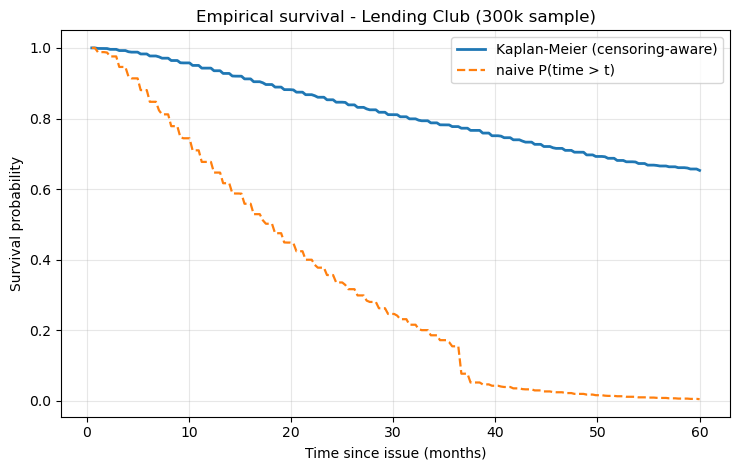

KM S(12m) = 0.9427   implied PD = 0.0573
KM S(24m) = 0.8530   implied PD = 0.1470
KM S(36m) = 0.7771   implied PD = 0.2229


In [12]:
from lifelines import KaplanMeierFitter

sample = df.sample(n=min(300_000, len(df)), random_state=42)
km = KaplanMeierFitter().fit(sample["time"], sample["event"])

grid = np.linspace(0.5, 60, 200)
naive = [(sample["time"] > t).mean() for t in grid]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(grid, km.predict(grid).values, lw=2, label="Kaplan-Meier (censoring-aware)")
ax.plot(grid, naive, lw=1.6, ls="--", label="naive P(time > t)")
ax.set_xlabel("Time since issue (months)")
ax.set_ylabel("Survival probability")
ax.set_title("Empirical survival - Lending Club (300k sample)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for h in (12, 24, 36):
    print(f"KM S({h:>2}m) = {float(km.predict(h)):.4f}   "
          f"implied PD = {1 - float(km.predict(h)):.4f}")

## Save the clean dataset

In [13]:
keep = ["loan_status", "issue_d", "last_pymnt_d", "term", "annual_inc",
        "emp_length", "int_rate", "loan_amnt", "dti", "grade",
        "home_ownership", "time", "event"]
out = df[keep]
out.to_csv(CLEAN_CSV, index=False)
print(f"wrote {CLEAN_CSV}")
print(f"shape {out.shape}")
print(f"size  {CLEAN_CSV.stat().st_size / 1e6:.1f} MB")
out.head()

wrote C:\Users\arora\Downloads\credit_survival_project-main (2)\data\lendingclub_survival_clean.csv
shape (2247571, 13)
size  221.5 MB


,loan_status,issue_d,last_pymnt_d,term,annual_inc,emp_length,int_rate,loan_amnt,dti,grade,home_ownership,time,event
0,Fully Paid,2015-12-01,2019-01-01,36.0,55000.0,10+ years,13.99,3600.0,5.91,C,MORTGAGE,37.566667,0
1,Fully Paid,2015-12-01,2016-06-01,36.0,65000.0,10+ years,11.99,24700.0,16.06,C,MORTGAGE,6.100000,0
2,Fully Paid,2015-12-01,2017-06-01,60.0,63000.0,10+ years,10.78,20000.0,10.78,B,MORTGAGE,18.266667,0
3,Current,2015-12-01,2019-02-01,60.0,110000.0,10+ years,14.85,35000.0,17.06,C,MORTGAGE,38.600000,0
4,Fully Paid,2015-12-01,2016-07-01,60.0,104433.0,3 years,22.45,10400.0,25.37,F,MORTGAGE,7.100000,0


## Summary

The dataset is written to `data/lendingclub_survival_clean.csv`. Every
subsequent notebook loads it through `src.common.load_data`, splits it with
`src.common.make_split` and builds features with `src.common.build_features`,
so all arms see identical rows and identical columns.

The attrition ledger above is the audit trail: raw row count in, row count after
each filter, final count and event rate out.